# 1. Setup


In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

THEMES_PDFS_DIR = PROJECT_ROOT / "docs" / "generated_pdfs"
themes_pdfs = sorted(THEMES_PDFS_DIR.glob("*.pdf"))

print("Project root:", PROJECT_ROOT)
print("Theme PDFs found:", len(themes_pdfs))
for pdf_file in themes_pdfs:
    print(f"- {pdf_file.name}: exists={pdf_file.exists()}")


Project root: c:\Users\User\Desktop\inmind\gatherly_rag
Theme PDFs found: 16
- Boho_Wedding.pdf: exists=True
- Celestial_Wedding.pdf: exists=True
- Classic_Wedding.pdf: exists=True
- Enchanted_Forest_Wedding.pdf: exists=True
- Garden_Wedding.pdf: exists=True
- Modern_Wedding.pdf: exists=True
- Moody_Wedding.pdf: exists=True
- Romantic_Wedding.pdf: exists=True
- Rustic_Wedding.pdf: exists=True
- Tropical_Wedding.pdf: exists=True
- Vintage_Wedding.pdf: exists=True
- Wedding_Centerpieces.pdf: exists=True
- Wedding_Colors.pdf: exists=True
- Wedding_Themes.pdf: exists=True
- Wedding_Trends.pdf: exists=True
- Whimsical_Wedding.pdf: exists=True


# 2. Import helpers


In [2]:
images_module = importlib.import_module("doc_rag.3_images")
images_module = importlib.reload(images_module)

inspect_page_images = images_module.inspect_page_images
extract_pdf_image = images_module.extract_embedded_image


# 3. Inspect images in theme PDFs


## 3.1 Inventory raster images across all pages


In [3]:
import pymupdf

image_inventory_rows = []

for pdf_file in themes_pdfs:
    with pymupdf.open(pdf_file) as pdf:
        page_count = pdf.page_count

    for page_number in range(1, page_count + 1):
        page_images = inspect_page_images(pdf_file, page_number)
        extractable_images = sum(image["xref"] > 0 for image in page_images)
        image_inventory_rows.append({
            "file_name": pdf_file.name,
            "source_path": str(pdf_file),
            "page_number": page_number,
            "image_count": len(page_images),
            "extractable_images": extractable_images,
        })

image_inventory = pd.DataFrame(image_inventory_rows)
image_inventory


,file_name,source_path,page_number,image_count,extractable_images
0,Boho_Wedding.pdf,c:\Users\User\Desktop\inmind\gatherly_rag\docs...,1,1,1
1,Boho_Wedding.pdf,c:\Users\User\Desktop\inmind\gatherly_rag\docs...,2,2,2
2,Boho_Wedding.pdf,c:\Users\User\Desktop\inmind\gatherly_rag\docs...,3,3,3
3,Boho_Wedding.pdf,c:\Users\User\Desktop\inmind\gatherly_rag\docs...,4,1,1
4,Boho_Wedding.pdf,c:\Users\User\Desktop\inmind\gatherly_rag\docs...,5,2,2
...,...,...,...,...,...
320,Whimsical_Wedding.pdf,c:\Users\User\Desktop\inmind\gatherly_rag\docs...,16,4,4
321,Whimsical_Wedding.pdf,c:\Users\User\Desktop\inmind\gatherly_rag\docs...,17,3,3
322,Whimsical_Wedding.pdf,c:\Users\User\Desktop\inmind\gatherly_rag\docs...,18,3,1
323,Whimsical_Wedding.pdf,c:\Users\User\Desktop\inmind\gatherly_rag\docs...,19,2,1


## 3.2 Image coverage by document


In [4]:
image_coverage = (
    image_inventory.groupby("file_name", sort=False)
    .agg(
        page_count=("page_number", "count"),
        total_images=("image_count", "sum"),
        pages_with_images=("image_count", lambda values: int((values > 0).sum())),
        extractable_images=("extractable_images", "sum"),
    )
)
display(image_coverage)
print("Total page placements:", int(image_coverage["total_images"].sum()))
print("Total extractable placements:", int(image_coverage["extractable_images"].sum()))


,page_count,total_images,pages_with_images,extractable_images
file_name,,,,
Boho_Wedding.pdf,32,70,32,68
Celestial_Wedding.pdf,13,44,13,41
Classic_Wedding.pdf,16,25,11,22
Enchanted_Forest_Wedding.pdf,23,20,13,17
Garden_Wedding.pdf,25,74,21,70
Modern_Wedding.pdf,30,58,27,58
Moody_Wedding.pdf,18,49,16,46
Romantic_Wedding.pdf,19,54,15,51
Rustic_Wedding.pdf,40,74,28,71


Total page placements: 677
Total extractable placements: 635


## 3.3 PDF image metadata sample


In [5]:
selected_image_rows = []

for pdf_file in themes_pdfs:
    pages = image_inventory.loc[
        image_inventory["file_name"] == pdf_file.name, "page_number"
    ]
    for page_number in pages:
        for image in inspect_page_images(pdf_file, int(page_number)):
            selected_image_rows.append({
                "file_name": pdf_file.name,
                "source_path": str(pdf_file),
                "page_number": int(page_number),
                **image,
            })

selected_image_metadata = pd.DataFrame(selected_image_rows)
print("Image placements:", len(selected_image_metadata))
print(
    "Unique extractable xrefs:",
    selected_image_metadata.loc[selected_image_metadata["xref"] > 0]
    .groupby(["source_path", "xref"])
    .ngroups,
)
display(selected_image_metadata.head(20))


Image placements: 677
Unique extractable xrefs: 567


,file_name,source_path,page_number,image_index,xref,bbox,width,height,colorspace,bits_per_component,has_mask
0,Boho_Wedding.pdf,c:\Users\User\Desktop\inmind\gatherly_rag\docs...,1,1,841,"[30.75, 612.0, 287.25, 996.75]",534,800,"ICCBased(RGB,Google/Skia/7C5FA2151397474A0486B...",8,False
1,Boho_Wedding.pdf,c:\Users\User\Desktop\inmind\gatherly_rag\docs...,2,1,844,"[30.75, -231.0, 287.25, 153.75]",267,400,"ICCBased(RGB,Google/Skia/7C5FA2151397474A0486B...",8,False
2,Boho_Wedding.pdf,c:\Users\User\Desktop\inmind\gatherly_rag\docs...,2,2,845,"[30.75, 663.0, 287.25, 1090.5]",600,1000,"ICCBased(RGB,Google/Skia/7C5FA2151397474A0486B...",8,False
3,Boho_Wedding.pdf,c:\Users\User\Desktop\inmind\gatherly_rag\docs...,3,1,846,"[30.75, -180.0, 287.25, 247.5]",300,500,"ICCBased(RGB,Google/Skia/7C5FA2151397474A0486B...",8,False
4,Boho_Wedding.pdf,c:\Users\User\Desktop\inmind\gatherly_rag\docs...,3,2,847,"[30.75, 305.25, 287.25, 690.0]",1024,1534,"ICCBased(RGB,Google/Skia/7C5FA2151397474A0486B...",8,False
5,Boho_Wedding.pdf,c:\Users\User\Desktop\inmind\gatherly_rag\docs...,3,3,848,"[30.75, 747.75, 287.25, 1132.5]",854,1280,"ICCBased(RGB,Google/Skia/7C5FA2151397474A0486B...",8,False
6,Boho_Wedding.pdf,c:\Users\User\Desktop\inmind\gatherly_rag\docs...,4,1,849,"[30.75, -95.25, 287.25, 289.5]",427,640,"ICCBased(RGB,Google/Skia/7C5FA2151397474A0486B...",8,False
7,Boho_Wedding.pdf,c:\Users\User\Desktop\inmind\gatherly_rag\docs...,5,1,850,"[30.75, 100.5, 287.25, 485.25]",854,1280,"ICCBased(RGB,Google/Skia/7C5FA2151397474A0486B...",8,False
8,Boho_Wedding.pdf,c:\Users\User\Desktop\inmind\gatherly_rag\docs...,5,2,851,"[30.75, 691.5, 287.25, 1072.5]",1000,1486,"ICCBased(RGB,Google/Skia/7C5FA2151397474A0486B...",8,False
9,Boho_Wedding.pdf,c:\Users\User\Desktop\inmind\gatherly_rag\docs...,6,1,851,"[30.75, -151.5, 287.25, 229.5]",1000,1486,"ICCBased(RGB,Google/Skia/7C5FA2151397474A0486B...",8,False


## 3.4 Extract a sample of PDF images


Boho_Wedding.pdf - page 1 - xref 841 - 534×800 - jpeg


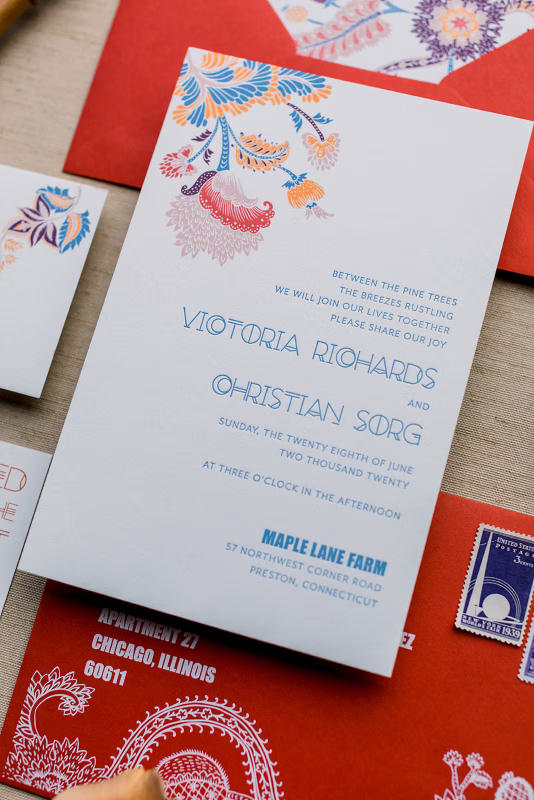

Celestial_Wedding.pdf - page 1 - xref 396 - 1350×900 - jpeg


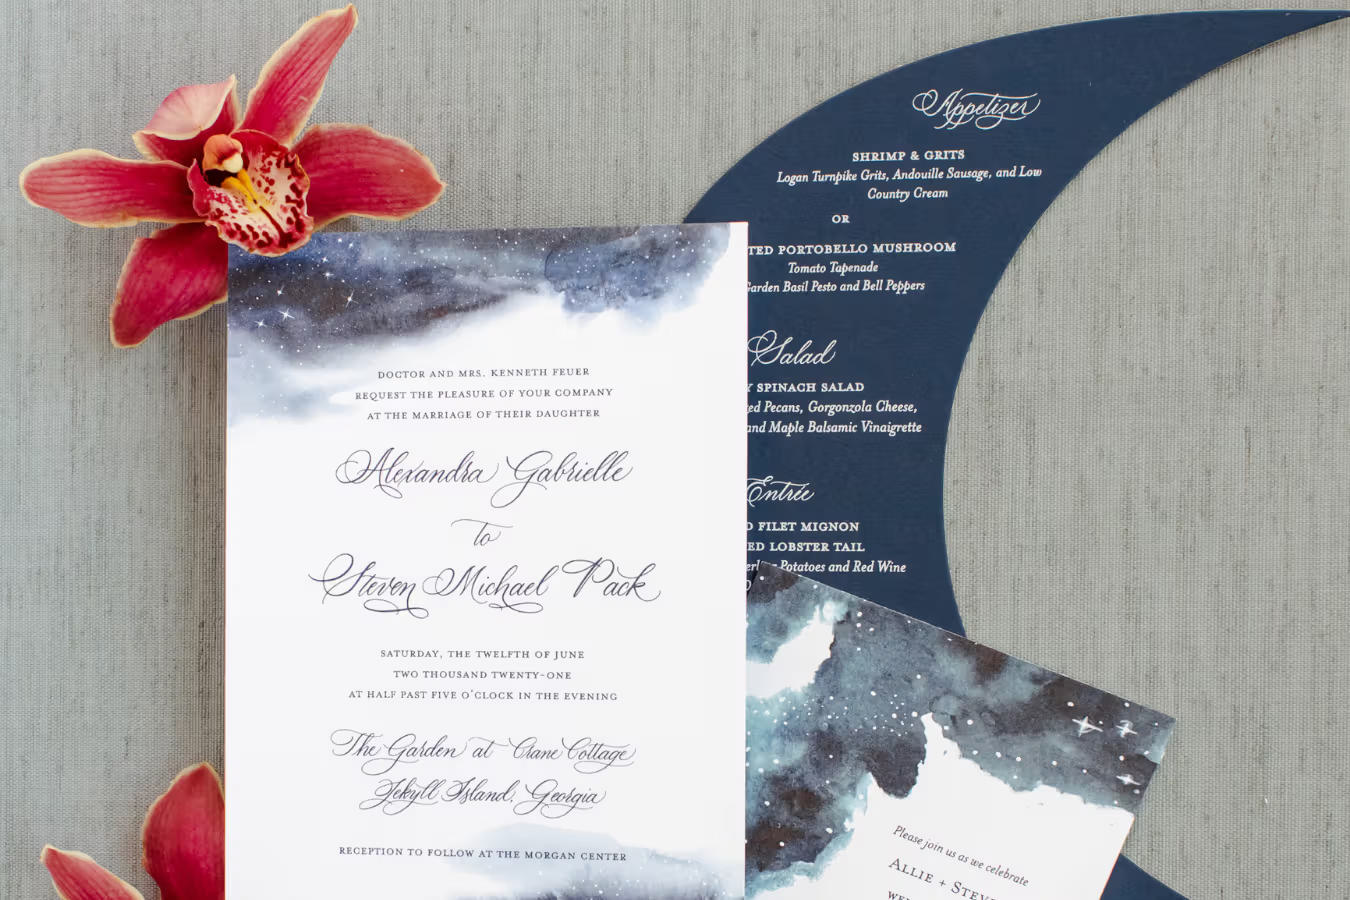

Classic_Wedding.pdf - page 4 - xref 485 - 640×480 - jpeg


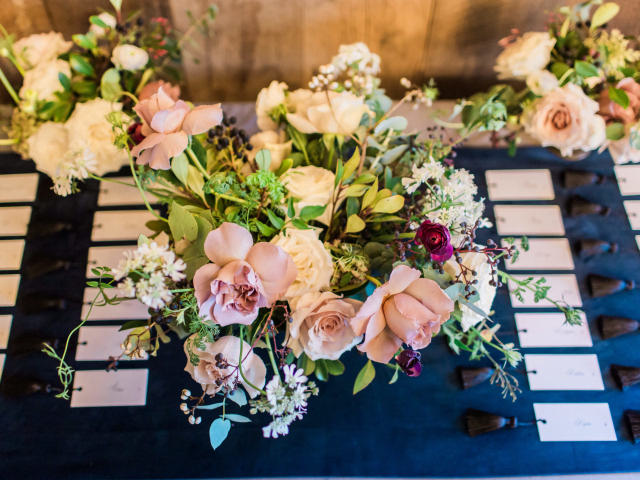

Enchanted_Forest_Wedding.pdf - page 1 - xref 546 - 1024×683 - jpeg


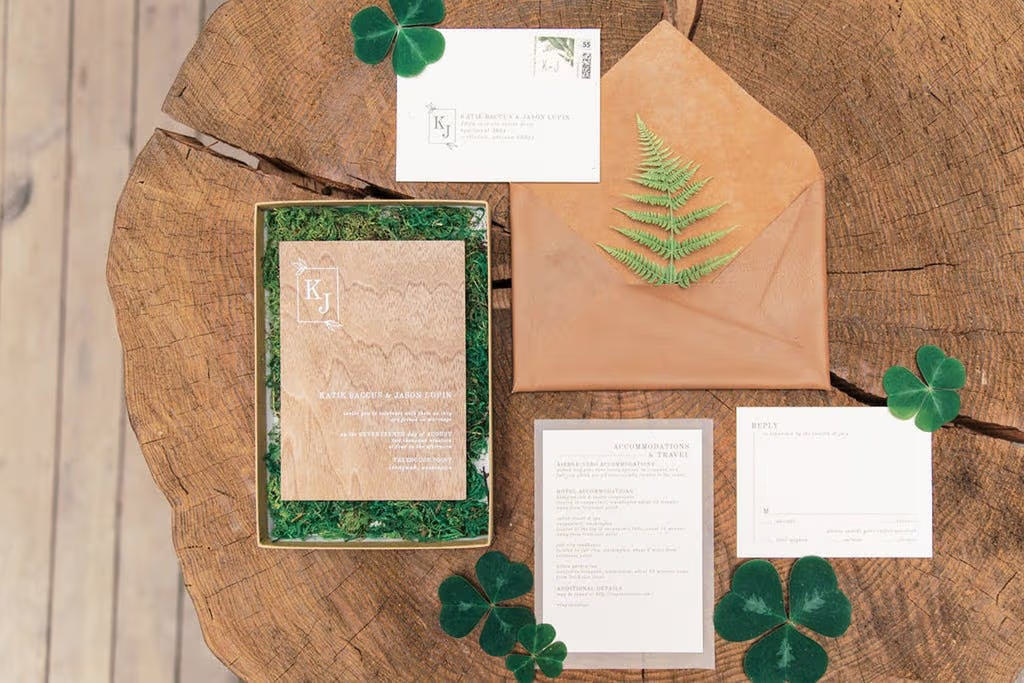

Garden_Wedding.pdf - page 3 - xref 606 - 750×500 - jpeg


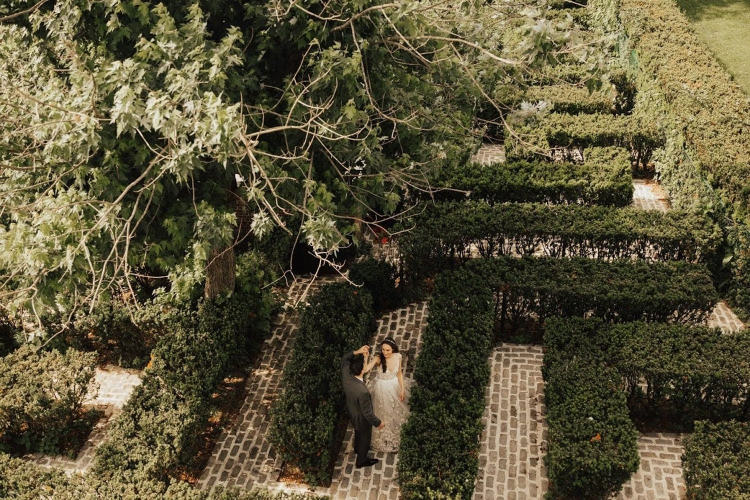

Modern_Wedding.pdf - page 3 - xref 935 - 650×975 - jpeg


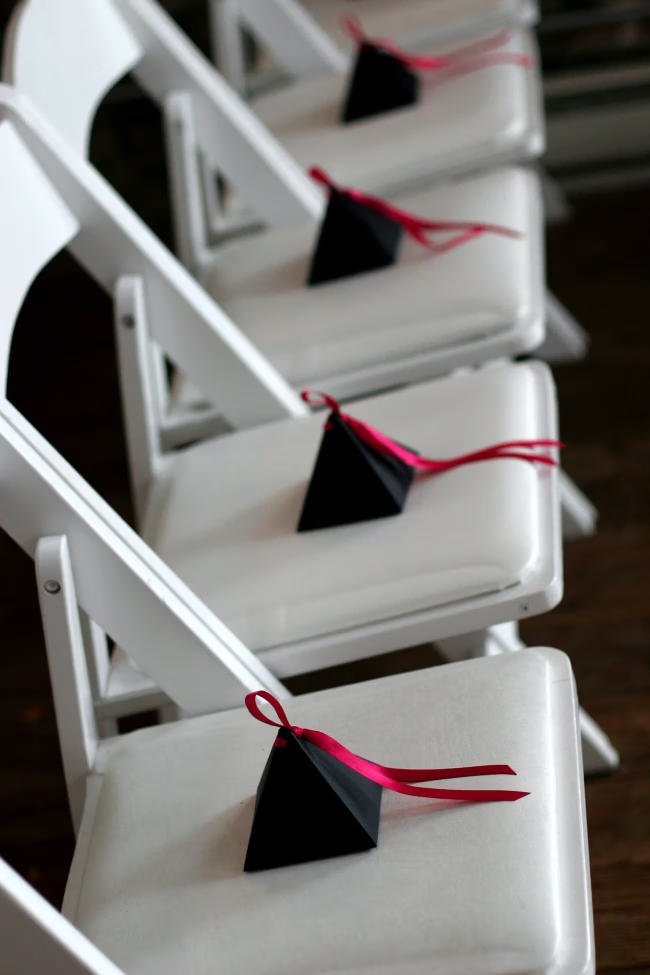

Moody_Wedding.pdf - page 1 - xref 496 - 1280×854 - jpeg


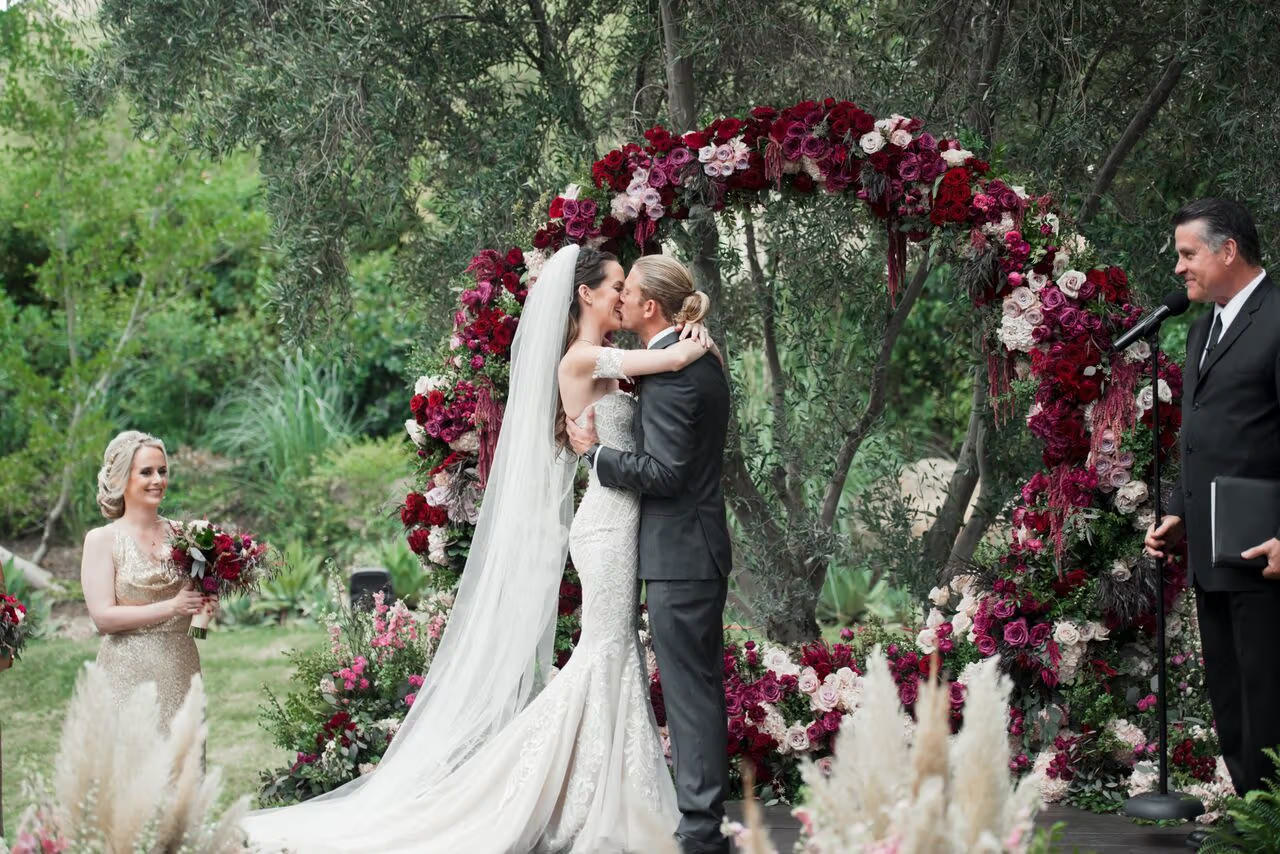

Romantic_Wedding.pdf - page 3 - xref 539 - 1280×854 - jpeg


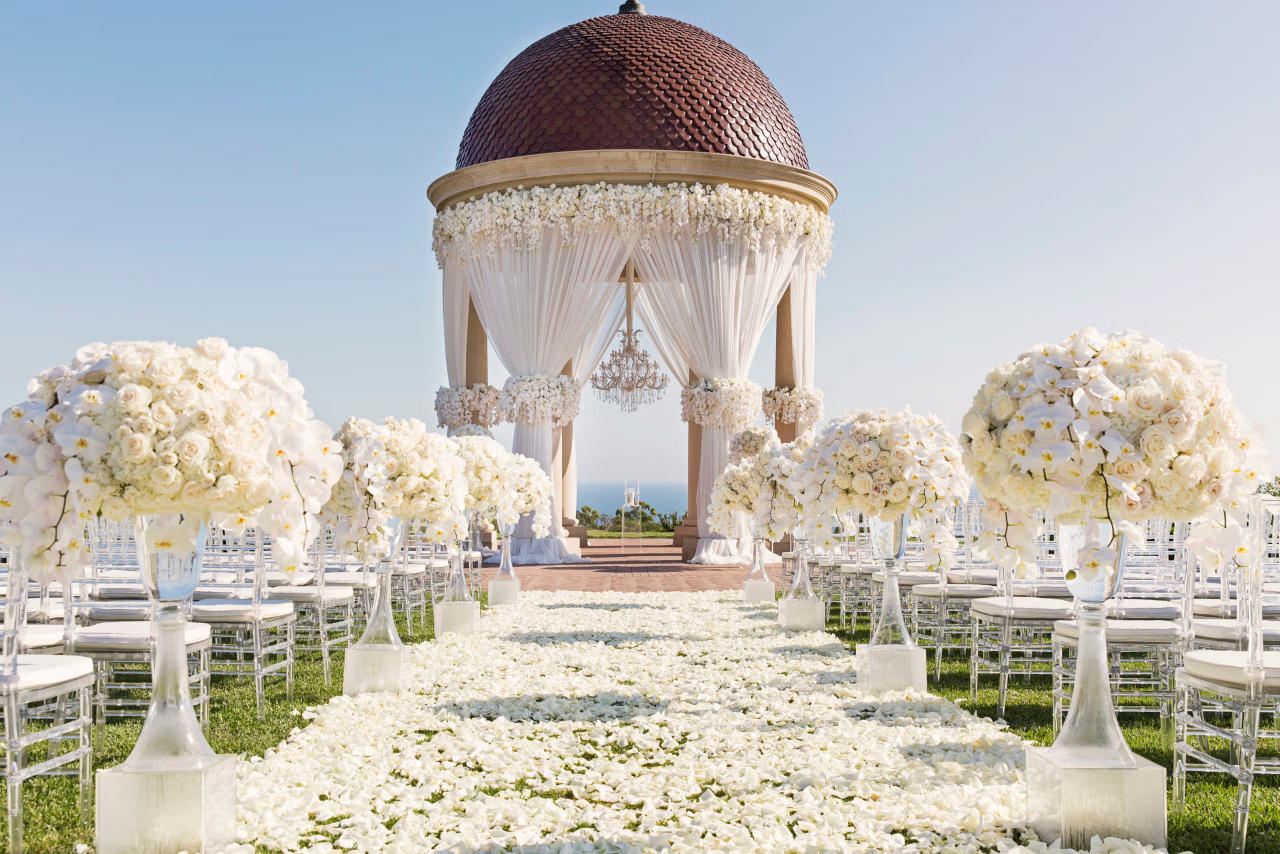

Displayed 8 sample image(s).


In [9]:
SAMPLE_PER_PDF = 1
MAX_SAMPLES = 8

displayed_images = set()
shown = 0

for pdf_file in themes_pdfs:
    if shown >= MAX_SAMPLES:
        break

    per_pdf = 0
    for row in selected_image_rows:
        if row["file_name"] != pdf_file.name:
            continue
        xref = row["xref"]
        image_key = (row["source_path"], xref)
        if xref <= 0 or image_key in displayed_images:
            continue

        displayed_images.add(image_key)
        extracted = extract_pdf_image(row["source_path"], xref)
        print(
            f"{row['file_name']} - page {row['page_number']} - "
            f"xref {xref} - {extracted['width']}×{extracted['height']} - "
            f"{extracted['extension']}"
        )
        display(Image(data=extracted["image_bytes"]))

        per_pdf += 1
        shown += 1
        if per_pdf >= SAMPLE_PER_PDF or shown >= MAX_SAMPLES:
            break

print(f"Displayed {shown} sample image(s).")


# 4. Image split across PDF pages

Some theme images continue from one page onto the next.


In [7]:
SPLIT_IMAGE_PDF = THEMES_PDFS_DIR / "Boho_Wedding.pdf"
SPLIT_IMAGE_PAGES = [5, 6]

print("PDF:", SPLIT_IMAGE_PDF)
print("Exists:", SPLIT_IMAGE_PDF.exists())
print("Pages:", SPLIT_IMAGE_PAGES)

split_image_rows = []
for page_number in SPLIT_IMAGE_PAGES:
    for image in inspect_page_images(SPLIT_IMAGE_PDF, page_number):
        split_image_rows.append({"page_number": page_number, **image})

split_image_metadata = pd.DataFrame(split_image_rows)
display(split_image_metadata)


PDF: c:\Users\User\Desktop\inmind\gatherly_rag\docs\generated_pdfs\Boho_Wedding.pdf
Exists: True
Pages: [5, 6]


,page_number,image_index,xref,bbox,width,height,colorspace,bits_per_component,has_mask
0,5,1,850,"[30.75, 100.5, 287.25, 485.25]",854,1280,"ICCBased(RGB,Google/Skia/7C5FA2151397474A0486B...",8,False
1,5,2,851,"[30.75, 691.5, 287.25, 1072.5]",1000,1486,"ICCBased(RGB,Google/Skia/7C5FA2151397474A0486B...",8,False
2,6,1,851,"[30.75, -151.5, 287.25, 229.5]",1000,1486,"ICCBased(RGB,Google/Skia/7C5FA2151397474A0486B...",8,False
3,6,2,852,"[30.75, 291.75, 287.25, 677.25]",854,1280,"ICCBased(RGB,Google/Skia/7C5FA2151397474A0486B...",8,False


,page_number,image_index,xref,digest,bbox,visible_fraction,touches_top,touches_bottom,fully_inside_page
0,5,1,850,3b2ae1b8178926168397f33cf42a6d3c,"(30.75, 100.5, 287.25, 485.25)",1.0000,False,False,True
1,5,2,851,18ce1a843824e1822b56a1b3cdfe5c45,"(30.75, 691.5, 287.25, 1072.5)",0.3973,False,True,False
2,6,1,851,18ce1a843824e1822b56a1b3cdfe5c45,"(30.75, -151.5, 287.25, 229.5)",0.6024,True,False,False
3,6,2,852,a488ed860056ed154c5d2d70477079fb,"(30.75, 291.75, 287.25, 677.25)",1.0000,False,False,True


RESULT: the same PDF image continues across the page boundary.
Matching digest(s): ['18ce1a843824e1822b56a1b3cdfe5c45']
xref 851 | 1000×1486 | jpeg


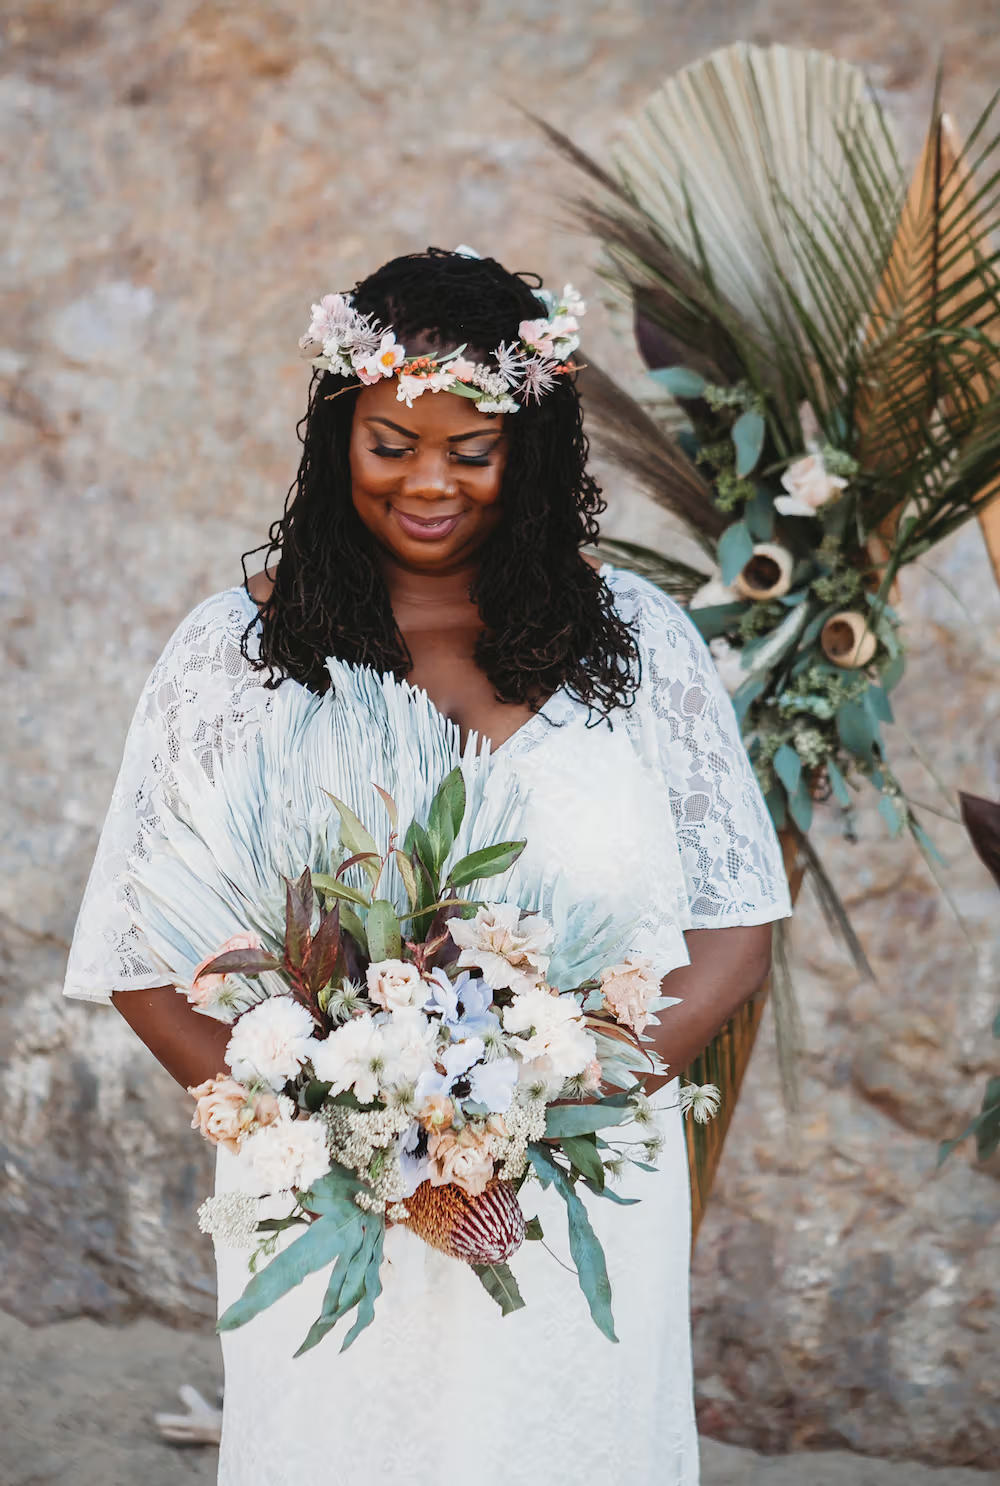

In [8]:
placement_rows = []

with pymupdf.open(SPLIT_IMAGE_PDF) as pdf:
    for page_number in SPLIT_IMAGE_PAGES:
        page = pdf[page_number - 1]
        page_rect = page.rect
        for image_index, image in enumerate(page.get_image_info(xrefs=True), start=1):
            bbox = pymupdf.Rect(image["bbox"])
            visible_rect = bbox & page_rect
            image_area = max(bbox.width * bbox.height, 0)
            visible_area = max(visible_rect.width * visible_rect.height, 0)
            visible_fraction = visible_area / image_area if image_area else 0
            placement_rows.append({
                "page_number": page_number,
                "image_index": image_index,
                "xref": int(image.get("xref", 0)),
                "digest": image["digest"].hex(),
                "bbox": tuple(round(value, 2) for value in bbox),
                "visible_fraction": round(visible_fraction, 4),
                "touches_top": bbox.y0 <= page_rect.y0 + 1,
                "touches_bottom": bbox.y1 >= page_rect.y1 - 1,
                "fully_inside_page": page_rect.contains(bbox),
            })

placements = pd.DataFrame(placement_rows)
display(placements)

page_a_bottom = placements[
    (placements["page_number"] == SPLIT_IMAGE_PAGES[0]) & placements["touches_bottom"]
]
page_b_top = placements[
    (placements["page_number"] == SPLIT_IMAGE_PAGES[1]) & placements["touches_top"]
]
shared_digests = set(page_a_bottom["digest"]) & set(page_b_top["digest"])
clipped = placements[~placements["fully_inside_page"]]

if shared_digests:
    print("RESULT: the same PDF image continues across the page boundary.")
    print("Matching digest(s):", sorted(shared_digests))
    shared_xrefs = (
        placements.loc[placements["digest"].isin(shared_digests), "xref"]
        .drop_duplicates()
        .tolist()
    )
    for xref in shared_xrefs:
        if xref <= 0:
            continue
        extracted = extract_pdf_image(SPLIT_IMAGE_PDF, int(xref))
        print(
            f"xref {xref} | {extracted['width']}×{extracted['height']} | "
            f"{extracted['extension']}"
        )
        display(Image(data=extracted["image_bytes"]))
elif not clipped.empty:
    print("RESULT: at least one image is clipped by a page boundary.")
    display(clipped)
else:
    print("RESULT: every detected image renders fully inside its PDF page.")
